# Motivation and Inspiration: 

# Methodology: 

# Exploratory Data Analysis: 

In [51]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scripts import data_cleaning

                    Player  Season Ending Year       Age Team     Games  \
2      Kareem Abdul-Jabbar              1980.0  1.326941  LAL  1.181217   
3            Tom Abernethy              1980.0 -0.378937  GSW  0.592080   
4              Alvan Adams              1980.0 -0.378937  PHO  0.906286   
5           Tiny Archibald              1980.0  1.083244  BOS  1.102665   
6            Dennis Awtrey              1980.0  1.083244  CHI -1.018228   
...                    ...                 ...       ...  ...       ...   
21633         Delon Wright              2025.0  1.326941  MIL -0.468367   
21634   Guerschon Yabusele              2025.0  0.595851  PHI  0.709907   
21635         Jahmir Young              2025.0 -0.622634  CHI -1.803744   
21636           Trae Young              2025.0 -0.135240  ATL  0.945562   
21637          Ivica Zubac              2025.0  0.108457  LAC  1.102665   

       Minutes per game  FGA per game  2PA per game  3PA per game  \
2              1.776700      1

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

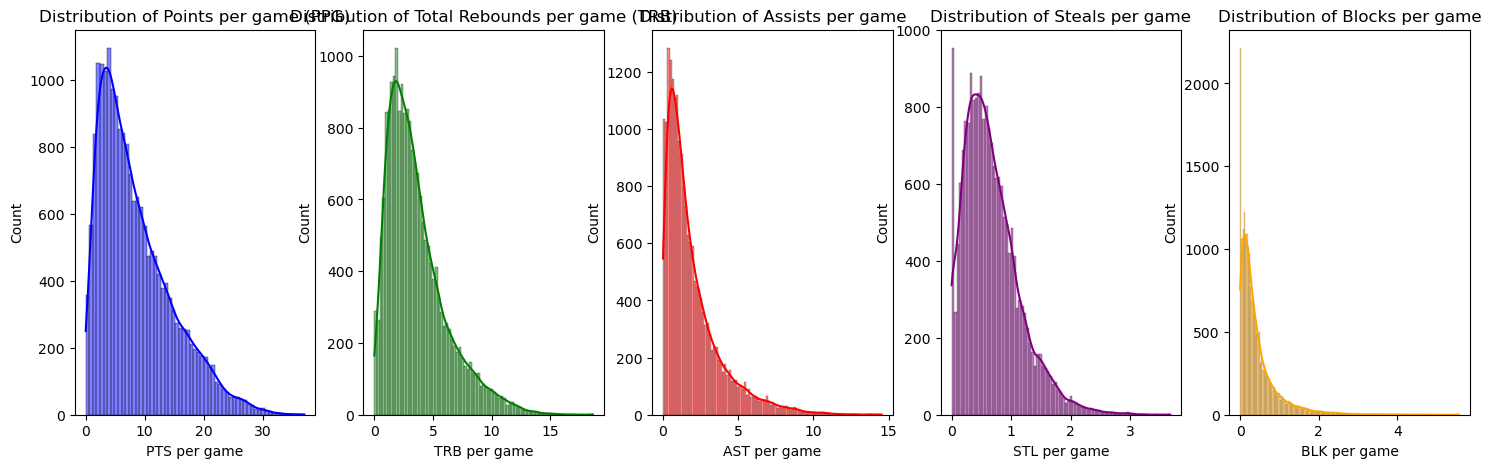

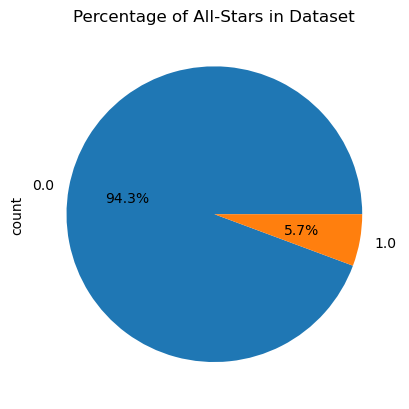

In [52]:
# Look at the distribution of Points
df = data_cleaning.df_clean

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
sns.histplot(data =df, x='PTS per game', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Points per game (PPG)')

sns.histplot(data =df, x='TRB per game', kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Total Rebounds per game (TRB)')

sns.histplot(data =df, x='AST per game', kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Assists per game')

sns.histplot(data =df, x='STL per game', kde=True, ax=axes[3], color='purple')
axes[3].set_title('Distribution of Steals per game')

sns.histplot(data =df, x='BLK per game', kde=True, ax=axes[4], color='orange')
axes[4].set_title('Distribution of Blocks per game')

plt.show()

df['All Star'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of All-Stars in Dataset')
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a

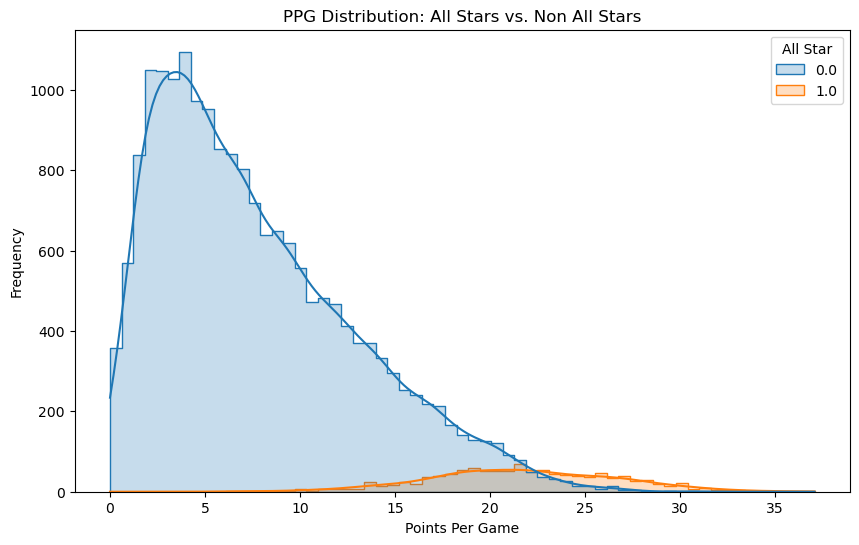

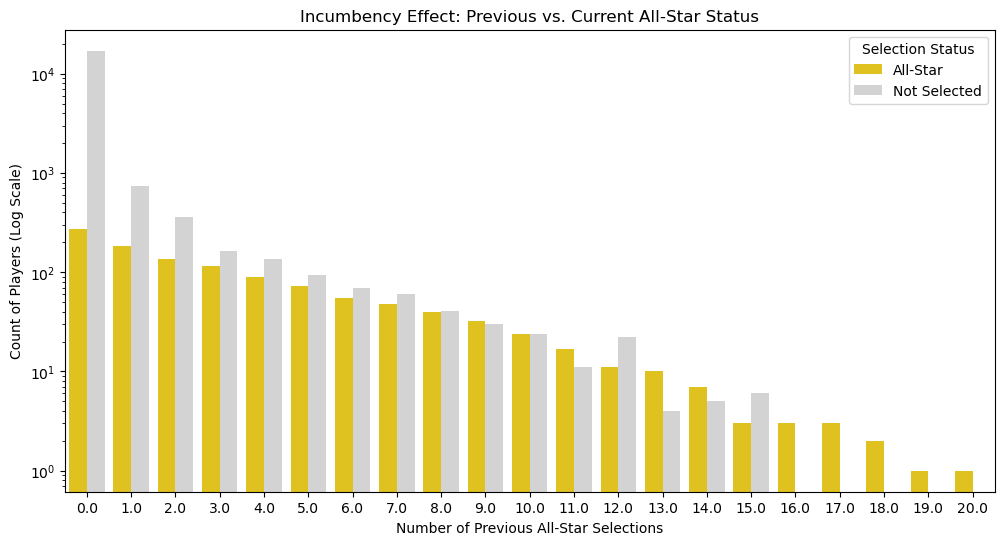

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


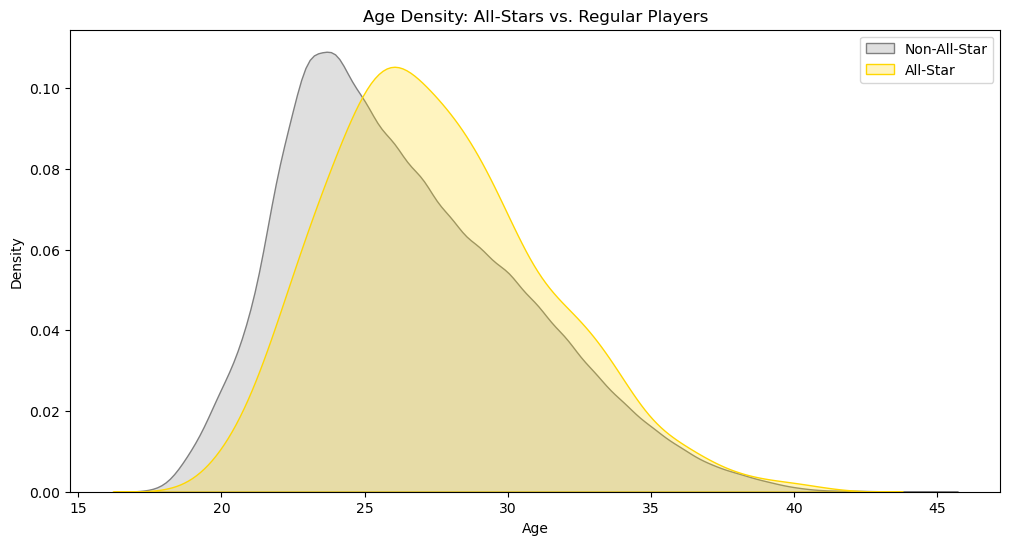

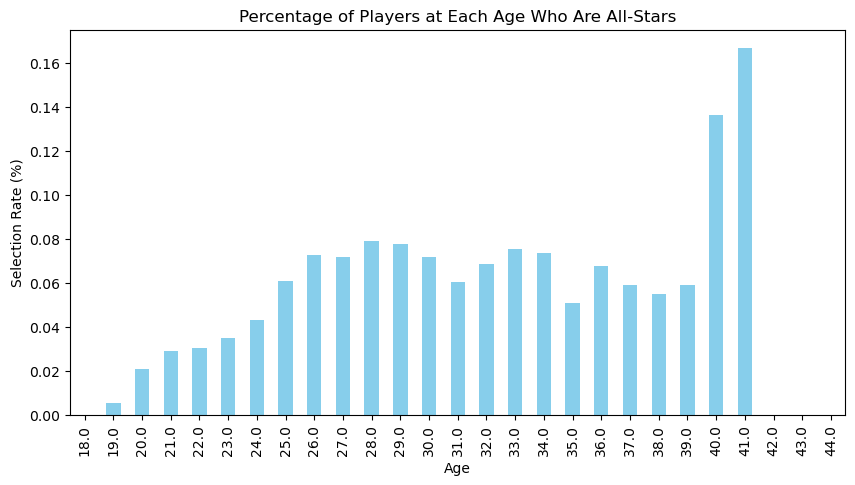

In [53]:
plt.figure(figsize=(10, 6))
# 'hue' splits the data by the All-Star column
sns.histplot(data=df, x='PTS per game', hue='All Star', kde=True, element="step")

plt.title('PPG Distribution: All Stars vs. Non All Stars')
plt.xlabel('Points Per Game')
plt.ylabel('Frequency')
plt.show()


#  temporary column for plotting with string labels
df['Selection Status'] = df['All Star'].map({0: 'Not Selected', 1: 'All-Star'})
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='Prev All Stars', hue='Selection Status', 
              palette={'Not Selected': 'lightgrey', 'All-Star': 'gold'})

plt.yscale('log')
plt.title('Incumbency Effect: Previous vs. Current All-Star Status')
plt.xlabel('Number of Previous All-Star Selections')
plt.ylabel('Count of Players (Log Scale)')

# remove the temporary column after plotting
df.drop('Selection Status', axis=1, inplace=True)

plt.show()


plt.figure(figsize=(12, 6))
sns.kdeplot(df[df['All Star'] == 0]['Age'], label='Non-All-Star', fill=True, color='gray')
sns.kdeplot(df[df['All Star'] == 1]['Age'], label='All-Star', fill=True, color='gold')

plt.title('Age Density: All-Stars vs. Regular Players')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

age_success = df.groupby('Age')['All Star'].mean()
plt.figure(figsize=(10, 5))
age_success.plot(kind='bar', color='skyblue')
plt.title('Percentage of Players at Each Age Who Are All-Stars')
plt.ylabel('Selection Rate (%)')
plt.show()

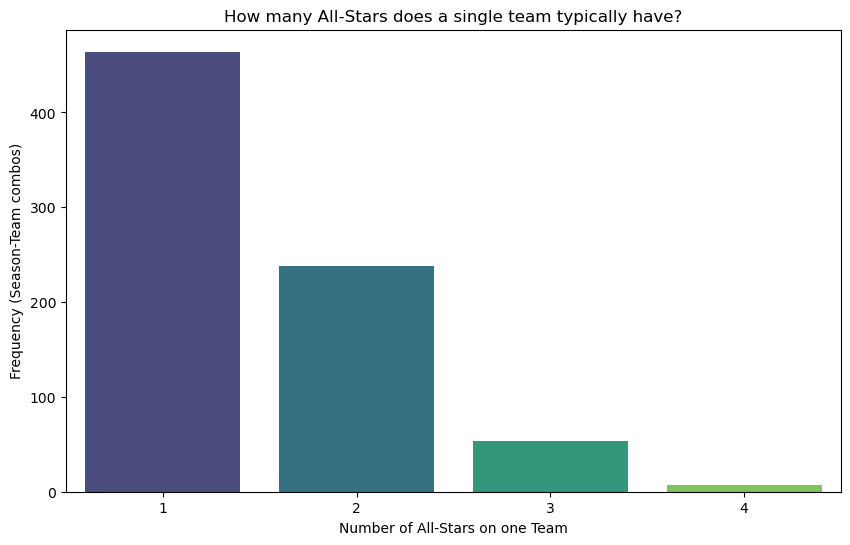

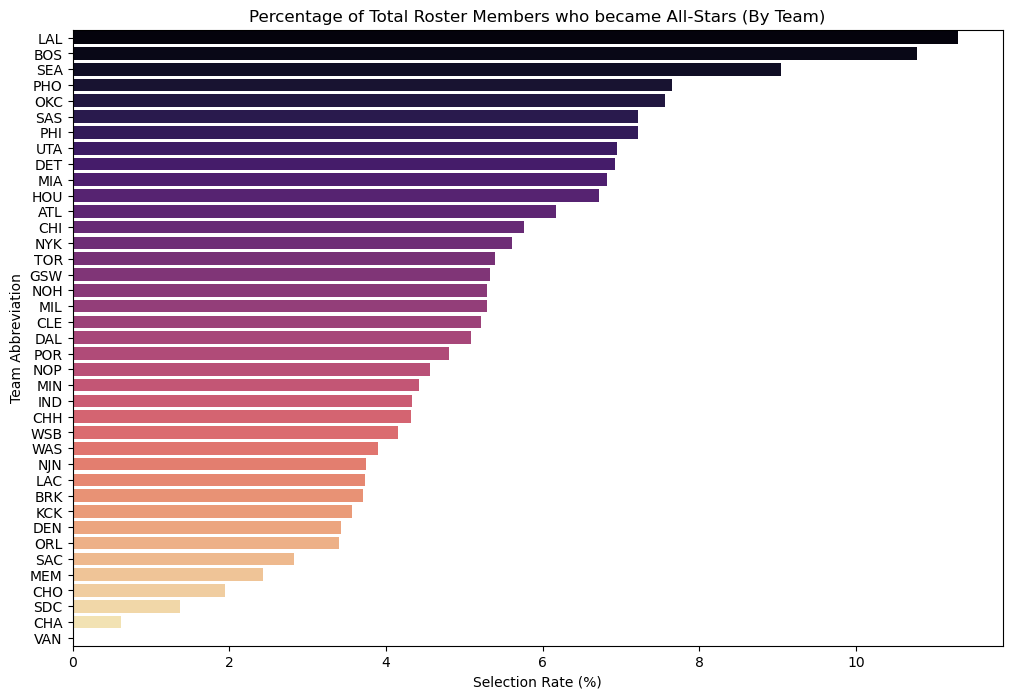

In [54]:
as_counts = df[df['All Star'] == 1].groupby(['Team', 'Season Ending Year']).size().reset_index(name='AS_Count')


plt.figure(figsize=(10, 6))
sns.countplot(data=as_counts, x='AS_Count', palette='viridis')
plt.title('How many All-Stars does a single team typically have?')
plt.xlabel('Number of All-Stars on one Team')
plt.ylabel('Frequency (Season-Team combos)')
plt.show()


total_players = df.groupby('Team').size()
total_all_stars = df[df['All Star'] == 1].groupby('Team').size()
team_rate = (total_all_stars / total_players * 100).sort_values(ascending=False).fillna(0)

# 4. Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=team_rate.values, y=team_rate.index, palette="magma")
plt.title('Percentage of Total Roster Members who became All-Stars (By Team)')
plt.xlabel('Selection Rate (%)')
plt.ylabel('Team Abbreviation')
plt.show()

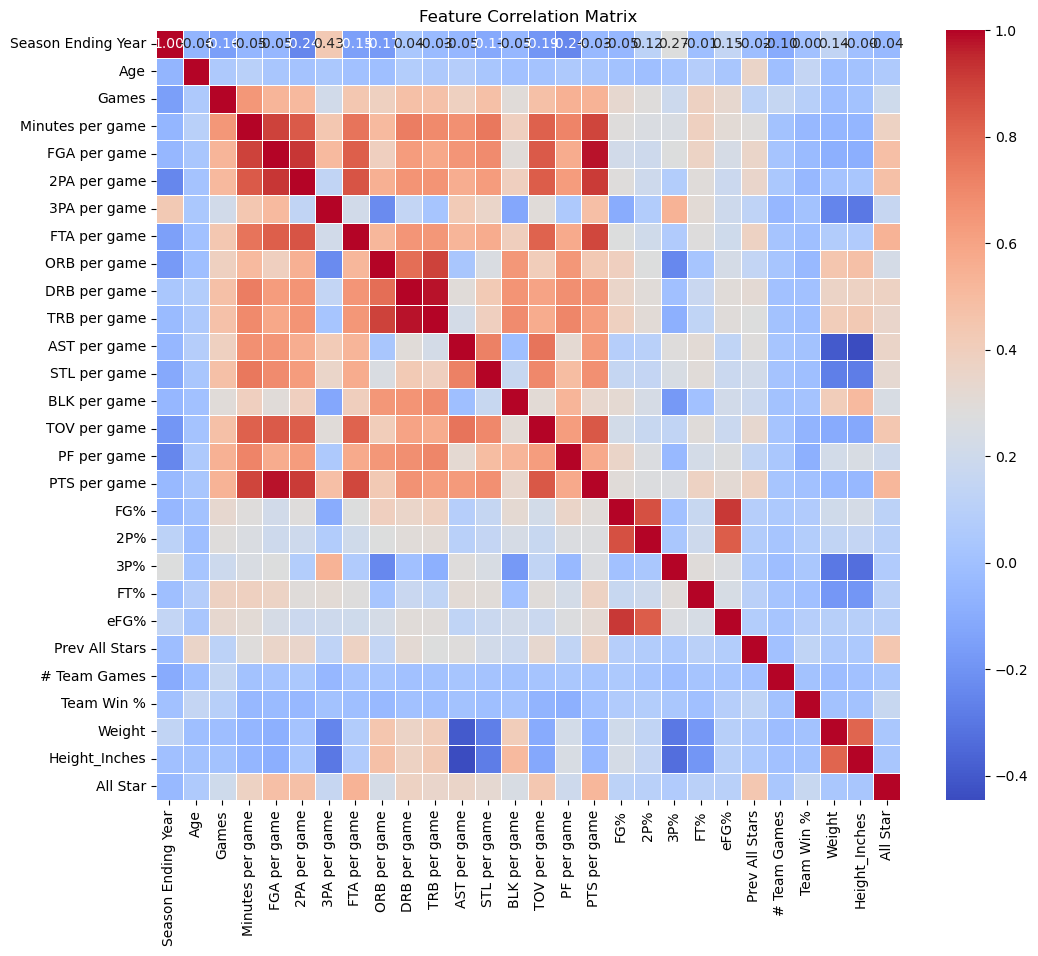

In [55]:

plt.figure(figsize=(12, 10))
# Calculate correlations
corr = df.select_dtypes(include=[np.number]).corr()

# Create the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# Data Cleaning and Processing: 

# Models: 

Starting with SVM and no feature transformations


In [56]:
%load_ext autoreload
%autoreload 2

from scripts import models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
base_svm = models.get_svm_model(kernel='rbf', C=1.0)
X_train, y_train = data_cleaning.X_train, data_cleaning.y_train
base_svm.fit(X_train, y_train)

models.evaluate_model(base_svm, X_train, y_train, "Training")

# Check performance on Validation set
X_val, y_val = data_cleaning.X_val, data_cleaning.y_val
models.evaluate_model(base_svm, X_val, y_val, "Validation")


--- Training Performance ---
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.98     11263
         1.0       0.56      1.00      0.72       676

    accuracy                           0.96     11939
   macro avg       0.78      0.98      0.85     11939
weighted avg       0.97      0.96      0.96     11939

Confusion Matrix:
[[10729   534]
 [    1   675]]
--- Detailed Confusion Matrix ---
                      Predicted: Not All-Star  Predicted: All-Star
Actual: Not All-Star                    10729                  534
Actual: All-Star                            1                  675
--- Validation Performance ---
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97      3754
         1.0       0.54      0.90      0.67       226

    accuracy                           0.95      3980
   macro avg       0.77      0.93      0.82      3980
weighted avg       0.97      0.95      0.96      3980

Co

SVM w no feature transformations, trying linear kernel

In [58]:
linear_svm = models.get_svm_model(kernel='linear', C=1.0)
X_train, y_train = data_cleaning.X_train, data_cleaning.y_train
linear_svm.fit(X_train, y_train)

models.evaluate_model(linear_svm, X_train, y_train, "Training")


# Check performance on Validation set
X_val, y_val = data_cleaning.X_val, data_cleaning.y_val
models.evaluate_model(linear_svm, X_val, y_val, "Validation")

--- Training Performance ---
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97     11263
         1.0       0.48      0.97      0.64       676

    accuracy                           0.94     11939
   macro avg       0.74      0.96      0.80     11939
weighted avg       0.97      0.94      0.95     11939

Confusion Matrix:
[[10547   716]
 [   17   659]]
--- Detailed Confusion Matrix ---
                      Predicted: Not All-Star  Predicted: All-Star
Actual: Not All-Star                    10547                  716
Actual: All-Star                           17                  659
--- Validation Performance ---
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.96      3754
         1.0       0.47      0.95      0.63       226

    accuracy                           0.94      3980
   macro avg       0.73      0.94      0.80      3980
weighted avg       0.97      0.94      0.95      3980

Co

SVM with no feature transforms, trying RBF w C = 0.1

In [59]:
svm_low_c = models.get_svm_model(kernel='rbf', C=0.1)
X_train, y_train = data_cleaning.X_train, data_cleaning.y_train
svm_low_c.fit(X_train, y_train)

models.evaluate_model(svm_low_c, X_train, y_train, "Training")

# Check performance on Validation set
X_val, y_val = data_cleaning.X_val, data_cleaning.y_val
models.evaluate_model(svm_low_c, X_val, y_val, "Validation")


--- Training Performance ---
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     11263
         1.0       0.45      0.99      0.62       676

    accuracy                           0.93     11939
   macro avg       0.73      0.96      0.79     11939
weighted avg       0.97      0.93      0.94     11939

Confusion Matrix:
[[10450   813]
 [    8   668]]
--- Detailed Confusion Matrix ---
                      Predicted: Not All-Star  Predicted: All-Star
Actual: Not All-Star                    10450                  813
Actual: All-Star                            8                  668
--- Validation Performance ---
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96      3754
         1.0       0.44      0.97      0.61       226

    accuracy                           0.93      3980
   macro avg       0.72      0.95      0.78      3980
weighted avg       0.97      0.93      0.94      3980

Co

# Results and Comparisons

# Conclusions and Final Remarks: 

# Data Sources

We aggregate multiple datasets to build a unified dataset of NBA team and player statistics.

## Team Data
- **Team Records Dataset**  
  Source: NBA Season Records from Every Year (Kaggle)  
  File: `Team_Records`  

- **Team Abbreviation Mapping**  
  Source: Historical NBA Data and Player Box Scores (Kaggle)  
  File: `TeamHistories.csv`  

## Player Data
- **Modern Player Data (1996–2023)**  
  Source: NBA Players Data (Kaggle)  
  File: `all_seasons.csv`  

- **Historical Player Data (1950–2017)**  
  Source: NBA Players Stats (Kaggle)  
  File: `player_data.csv`  

## Supplementary Sources
- Basketball Reference: https://www.basketball-reference.com  
- Stathead Player Season Finder:  
  https://www.sports-reference.com/stathead/basketball/player-season-finder.cgi  

These sources were used to:
- Fill missing seasons
- Validate inconsistencies
- Cross-check player and team statistics

---

## Data Coverage

We combine datasets across overlapping time periods:

$$
\text{Total Coverage} = [1950, 2023]
$$

with:
- Historical dataset: \(1950 \leq t \leq 2017\)
- Modern dataset: \(1996 \leq t \leq 2023\)

---

## Data Cleaning Notes

- Resolved team naming inconsistencies using `TeamHistories.csv`
- Imputed missing values using external references
- Standardized feature formats across datasets